In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import signal
import scipy.io as sio
import difflib
from collections import Counter
from scipy.linalg import toeplitz
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score

Keys in MAT file: ['__header__', '__version__', '__globals__', 'value']
EMG data shape: (8, 8000)
Plot saved as 'emg_plot.png'. Description: Multi-channel sEMG plot with time on x-axis and amplitude on y-axis for each channel.


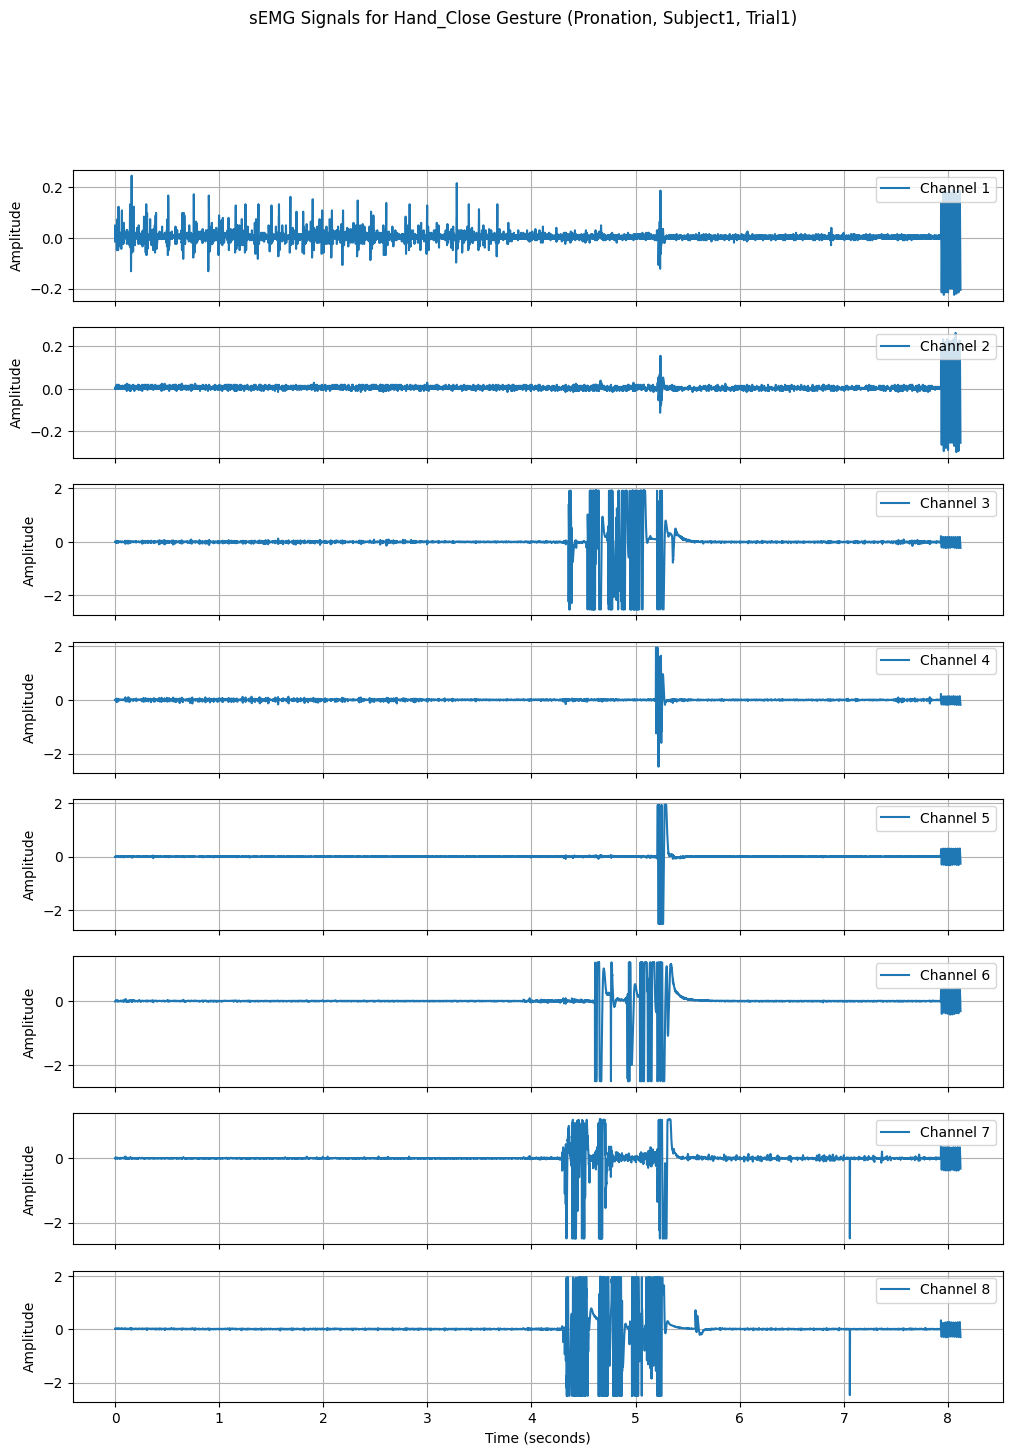

In [2]:
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import os

file_path = '/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG/Subject14/Pronation/Hand_Open-2.mat'

if os.path.exists(file_path):
    mat = sio.loadmat(file_path)
    keys = list(mat.keys())
    print("Keys in MAT file:", keys)
    data_key = keys[-1]  # Assuming the last key is the data matrix
    emg_data = mat[data_key]
    print("EMG data shape:", emg_data.shape)
    
    # Assuming data is samples x channels, transpose if necessary
    if emg_data.shape[0] == 8000:
        emg_data = emg_data.T  # To channels x samples
    
    sample_rate = 985
    num_channels = emg_data.shape[0]
    num_samples = emg_data.shape[1]
    time = np.arange(num_samples) / sample_rate
    
    fig, axs = plt.subplots(num_channels, 1, figsize=(12, 2*num_channels), sharex=True)
    fig.suptitle('sEMG Signals for Hand_Close Gesture (Pronation, Subject1, Trial1)')
    
    for ch in range(num_channels):
        axs[ch].plot(time, emg_data[ch], label=f'Channel {ch+1}')
        axs[ch].set_ylabel('Amplitude')
        axs[ch].legend(loc='upper right')
        axs[ch].grid(True)
    
    axs[-1].set_xlabel('Time (seconds)')
    
    # Instead of plt.show(), save to a temp file and print description
    plt.savefig('emg_plot.png')
    print("Plot saved as 'emg_plot.png'. Description: Multi-channel sEMG plot with time on x-axis and amplitude on y-axis for each channel.")
else:
    print("File not found at:", file_path)

In [3]:
BASE_PATH = ('/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/'
             'FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG')

N_FOLDS = 5
RANDOM_SEED = 200

sample_rate = 985
window_size_ms = 250
stride_ms = 250
window_size = int(window_size_ms / 1000 * sample_rate)
stride = int(stride_ms / 1000 * sample_rate)
num_channels = 8
notch_freq = 50.0 
q = 30.0

ONSET_ENV_MS = 150
ONSET_SUSTAIN_MS = 200
ONSET_FRAC = 0.2
ONSET_HI_PCT = 90
FALLBACK_ONSET_S = 0.5 

zc_threshold = 0.0
ssc_threshold = 0.0

gestures = ['Thumb_Up', 'Index', 'Right_Angle', 'Peace', 'Index_Little', 'Thumb_Little', 'Hand_Close', 'Hand_Open', 'Wrist_Extension', 'Wrist_Flexion', 'Ulnar_Deviation', 'Radial_Deviation']
gesture_map = {g: i for i, g in enumerate(gestures)}
orientations = ['pronation', 'rest', 'supination']
orientation_map = {o: i for i, o in enumerate(orientations)}

upper_orientations = ['Pronation', 'Rest', 'Supination']
upper_orientation_map = {o: i for i, o in enumerate(upper_orientations)}

SUBJECTS = [3]
FEATURES = 'combine'

In [4]:
def _detect_onset_s(emg, fs=sample_rate, env_ms=ONSET_ENV_MS, sustain_ms=ONSET_SUSTAIN_MS, frac=ONSET_FRAC, hi_pct=ONSET_HI_PCT):

    x = emg.astype(float)
    x = x - x.mean(axis=1, keepdims=True)              
    w = max(1, int(env_ms / 1000 * fs))
    if x.shape[1] < w:
        return None
    env = np.zeros(x.shape[1] - w + 1)
    for ch in x:
        env += np.sqrt(np.convolve(ch ** 2, np.ones(w) / w, mode='valid'))
    env /= x.shape[0]
 
    lo, hi = np.percentile(env, 5), np.percentile(env, hi_pct)   # hi robust (không dùng max)
    if hi - lo < 1e-9:
        return None
    envn = np.clip((env - lo) / (hi - lo), 0, None)
    sus = max(1, int(sustain_ms / 1000 * fs))
    above = envn > frac
    for i in range(len(above) - sus):
        if above[i:i + sus].all():
            return (i + w // 2) / fs
    return None

def crop_active(emg_trial, K=5.0, fs=sample_rate, fallback_onset_s=FALLBACK_ONSET_S, return_info=False):
    
    emg_trial = np.asarray(emg_trial)
    N = emg_trial.shape[1]
    win = int(round(K * fs))
 
    if N <= win:
        info = dict(onset_s=0.0, start=0, end=N, used_fallback=True, clamped=True, reason='signal<=win')
        return (emg_trial, info) if return_info else emg_trial
 
    onset_s = _detect_onset_s(emg_trial, fs=fs)
    used_fallback = onset_s is None
    if used_fallback:
        onset_s = fallback_onset_s
 
    start = int(round(onset_s * fs))
    end = start + win
    clamped = False
    if end > N:                          
        end = N
        start = N - win
        clamped = True
    if start < 0:                       
        start, end = 0, win
 
    crop = emg_trial[:, start:end]
    if return_info:
        return crop, dict(onset_s=round(onset_s, 3), start=start, end=end, dur_s=round((end - start) / fs, 3), used_fallback=used_fallback, clamped=clamped)
        
    return crop

def generate_folds_per_orientation(y_gesture, y_orientation, n_folds=N_FOLDS, seed=RANDOM_SEED):

    y_gesture = np.asarray(y_gesture)
    y_orientation = np.asarray(y_orientation)
    all_trial_idx = np.arange(len(y_gesture))

    fold_results = {}
    for ori in np.unique(y_orientation):
        ori_mask = (y_orientation == ori)
        ori_trial_idx = all_trial_idx[ori_mask]   # global trial indices for this orientation
        ori_gestures = y_gesture[ori_mask]        # gesture labels within this orientation
 
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        fold_results[ori] = {}
        # split() needs an X of the right length; labels drive the stratification
        for fold, (tr, te) in enumerate(skf.split(np.zeros(len(ori_gestures)), ori_gestures)):
            fold_results[ori][fold] = {
                'train_trial_idx': ori_trial_idx[tr],
                'test_trial_idx':  ori_trial_idx[te],
            }
    return fold_results

def print_fold_balance_check(fold_results, y_gesture, y_orientation, fold_num=0):
    y_gesture = np.asarray(y_gesture)
    print(f'\n=== Fold {fold_num} balance (per orientation) ===')
    for ori in sorted(fold_results.keys()):
        train = fold_results[ori][fold_num]['train_trial_idx']
        test = fold_results[ori][fold_num]['test_trial_idx']
        train_g = Counter(y_gesture[train]); test_g = Counter(y_gesture[test])
        print(f'  ori {ori}: train={len(train)} {dict(sorted(train_g.items()))} | '
              f'test={len(test)} {dict(sorted(test_g.items()))}')

def merge_orientations(fold_results, fold_num, orientations_to_use=None):
    if orientations_to_use is None:
        orientations_to_use = sorted(fold_results.keys())
    train_idx, test_idx = [], []
    for ori in orientations_to_use:
        train_idx.extend(fold_results[ori][fold_num]['train_trial_idx'].tolist())
        test_idx.extend(fold_results[ori][fold_num]['test_trial_idx'].tolist())
    return np.array(train_idx), np.array(test_idx)

def build_window_dataset(X_list, y_gesture, y_orientation, trial_idx_list, features):
    feats_list, g_labels, o_labels = [], [], []
    for ti in trial_idx_list:
        feat = process_trial(X_list[ti], features=features)   # [n_windows, F]
        if feat.ndim != 2 or feat.shape[0] == 0:
            print(f'[WARN] trial {ti} produced no windows — skipped')
            continue
        n_windows = feat.shape[0]
        feats_list.append(feat)
        g_labels.extend([y_gesture[ti]] * n_windows)
        o_labels.extend([y_orientation[ti]] * n_windows)
    X = np.vstack(feats_list)
    return X, np.array(g_labels), np.array(o_labels)

def ensure_channels_first(emg, n_ch=num_channels):
    emg = np.asarray(emg)
    if emg.ndim != 2:
        raise ValueError(f"EMG không phải 2D: shape {emg.shape}")
    if emg.shape[0] == n_ch:
        return emg
    if emg.shape[1] == n_ch:
        return emg.T
    raise ValueError(f"Không trục nào = {n_ch} kênh: shape {emg.shape}")

def load_data(base_path='/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG', subjects=None):
    if subjects is None:
        subjects = range(1, 20)
    X_list = []
    y_gesture_list = []
    y_orientation_list = []

    for subject in subjects:
        subject_path = os.path.join(base_path, f'Subject{subject}')
        if subject != 1:
            new_orientations = ['Pronation', 'Rest', 'Supination']
        else:
            new_orientations = orientations
        for ori in new_orientations:
            ori_path = os.path.join(subject_path, ori)
            for gest in gestures:
                for trial in range(1, 6):
                    if gest == 'Thumb_Up':
                        rename_gest = 'Thumb_UP'
                    elif gest == 'Ulnar_Deviation':
                        rename_gest = 'Ulner_Deviation'
                    else:
                        rename_gest = gest
                    file_name = f'{rename_gest}-{trial}.mat'
                    file_path = os.path.join(ori_path, file_name)
                    mat = sio.loadmat(file_path)
                    emg_data = mat[list(mat.keys())[-1]]
                    emg_trial = ensure_channels_first(emg_data) 
                    emg_trial = crop_active(emg_trial)
                    X_list.append(emg_trial)
                    y_gesture_list.append(gesture_map[gest])
                    if subject != 1:
                        y_orientation_list.append(upper_orientation_map[ori])
                    else:
                        y_orientation_list.append(orientation_map[ori])

    #print("Load data function")
    #print(f"[DEBUG] Loaded {len(X_list)} EMG trials")
    #for i, seg in enumerate(X_list[:5]):  # only preview first 5
    #    print(f"   Trial {i} shape: {seg.shape}")
        
    return X_list, np.array(y_gesture_list), np.array(y_orientation_list)

def signal_normalize_window(window, eps=1e-8):
    return window / np.sqrt(np.mean(window ** 2) + eps)
            
def apply_bandpass(data, fs=sample_rate, low=20, high=450):
    sos = signal.butter(4, [low, high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos, data, axis=1)
    return filtered

def apply_notch_filter(data, fs=sample_rate, freq=notch_freq, q=q):
    b, a = signal.iirnotch(freq, q, fs)
    filtered = signal.filtfilt(b, a, data, axis=1)
    return filtered

#def offset_correction(data):
#    return data - np.mean(data, axis=1, keepdims=True)

def extract_windows(data):
    num_samples = data.shape[1]
    windows = []
    for start in range(0, num_samples - window_size + 1, stride):
        window = data[:, start:start + window_size]
        windows.append(window)
    return np.array(windows)

def extract_hudgins_9_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mean_val = np.mean(np.abs(window), axis=1) 
    zc = np.sum(
        (np.diff(np.sign(window), axis=1) != 0)
        & (np.abs(np.diff(window, axis=1)) >= zc_threshold),
        axis=1,
    )
    
    mid   = window[:, 1:-1]
    left  = window[:, :-2]
    right = window[:, 2:]
    ssc = np.sum(((mid - left) * (mid - right)) > ssc_threshold, axis=1)
    
    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    rms = np.sqrt(np.mean(window**2, axis=1))
    var = np.var(window, axis=1)
    std = np.std(window, axis=1)
    mean_w = np.mean(window, axis=1, keepdims=True)
    std_w = np.where(std < 1e-8, 1e-8, std)[:, None]
    kurt = np.nan_to_num(np.mean(((window - mean_w) / std_w) ** 4, axis=1) - 3.0, nan=0.0)   
    skew = np.nan_to_num(np.mean(((window - mean_w) / std_w) ** 3, axis=1), nan=0.0)

    features = np.concatenate([mean_val, zc, ssc, wl, rms, var, std, kurt, skew])
    return features

def extract_hudgins_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mean_val = np.mean(np.abs(window), axis=1) 
    zc = np.sum(
        (np.diff(np.sign(window), axis=1) != 0)
        & (np.abs(np.diff(window, axis=1)) >= zc_threshold),
        axis=1,
    )
    
    mid   = window[:, 1:-1]
    left  = window[:, :-2]
    right = window[:, 2:]
    ssc = np.sum(((mid - left) * (mid - right)) > ssc_threshold, axis=1)

    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    features = np.concatenate([mean_val, zc, ssc, wl])
    return features

def extract_sntdf_features(window, eps=1e-8):
        
    d1 = np.diff(window, axis=1)
    d2 = np.diff(window, n=2, axis=1)
    d3 = np.diff(window, n=3, axis=1) 

    mean_val = np.log(np.mean(np.abs(window), axis=1) + eps)
    p0 = np.log(np.sum(window**2, axis=1) + eps)
    p2 = np.log(np.sum(d1**2, axis=1) + eps)
    p4 = np.log(np.sum(d2**2, axis=1) + eps)
    p6 = np.log(np.sum(d3**2, axis=1) + eps)

    ac1 = np.log(np.mean(np.abs(d1), axis=1) + eps)
    ac2 = np.log(np.mean(np.abs(d2), axis=1) + eps)

    corr = np.corrcoef(window)
    corr = np.nan_to_num(corr, nan=0.0) 
    corr_flat = corr[np.triu_indices(num_channels, k=1)] # Upper triangle

    features = np.concatenate([mean_val, p0, p2, p4, p6, ac1, ac2, corr_flat])

    return features
  
def process_trial(emg_trial, features='hudgin'):
    #print('to process trial')
    bandpassed = apply_bandpass(emg_trial)
    filtered = apply_notch_filter(bandpassed)
    windows = extract_windows(filtered)
    #corrected = offset_correction(filtered)
    #windows = extract_windows(corrected)
    feats = []
    for w in windows:
        if features=='hudgin':
            feats.append(extract_hudgins_features(w))
        elif features=='hudgin_9':
            feats.append(extract_hudgins_9_features(w))
        elif features == 'sntdf':
            feats.append(extract_sntdf_features(signal_normalize_window(w)))
        elif features == 'combine':
            feats.append(np.concatenate([
                extract_sntdf_features(signal_normalize_window(w)),        
                extract_hudgins_9_features(w),       
            ]))
        else:
            raise ValueError(f"Unsupported features: {features}")
            
    return np.array(feats)

def normalize_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)
    return X_train_norm, X_test_norm

def hmc_classification(X_train, X_test, yg_train, yg_test, yo_train, yo_test): 
    
    X_train_norm = np.asarray(X_train, dtype=np.float64)
    X_test_norm  = np.asarray(X_test,  dtype=np.float64)

    X_train_norm, X_test_norm = normalize_data(X_train_norm, X_test_norm)
        
    #clf_ori = SVC(kernel='rbf', C=1.0, gamma='scale')
    clf_ori = LinearDiscriminantAnalysis()
    clf_ori.fit(X_train_norm, yo_train)
        
    ori_pred_test = clf_ori.predict(X_test_norm)
    ori_pred_train = clf_ori.predict(X_train_norm)
    ori_acc = accuracy_score(yo_test, ori_pred_test)
    
    ori_pred_norm_test  = (ori_pred_test  - np.min(ori_pred_test))  / (np.max(ori_pred_test)  - np.min(ori_pred_test)  + 1e-8)
    ori_pred_norm_train = (ori_pred_train - np.min(ori_pred_train)) / (np.max(ori_pred_train) - np.min(ori_pred_train) + 1e-8)
    X_aug_train = np.hstack((X_train_norm, ori_pred_norm_train.reshape(-1, 1)))
    X_aug_test  = np.hstack((X_test_norm,  ori_pred_norm_test.reshape(-1, 1)))

    gesture_clfs = {}

    for ori in np.unique(yo_train):
        mask = (yo_train == ori)
        if len(np.unique(yg_train[mask])) > 1:
            clf_g = LinearDiscriminantAnalysis()
            clf_g.fit(X_aug_train[mask], yg_train[mask])
            gesture_clfs[ori] = clf_g
 
    preds_gesture = []
    for i in range(len(X_aug_test)):
        o_pred = ori_pred_test[i]
        x_aug = X_aug_test[i].reshape(1, -1)
        preds_gesture.append(gesture_clfs[o_pred].predict(x_aug)[0])
 
    preds_gesture = np.array(preds_gesture)
    multi_label_acc = np.mean((ori_pred_test == yo_test) & (preds_gesture == yg_test))
    soft_acc = accuracy_score(yg_test, preds_gesture)
    
    return ori_acc, multi_label_acc, soft_acc

In [5]:
if __name__ == '__main__':
 
    all_means = []
    for subj in SUBJECTS:
        # trial-level data (each X_list[i] is one trial: channels x samples)
        X_list, y_gesture, y_orientation = load_data(subjects=[subj])
        print(f'\n##### Subject {subj} #####')
        print(f'Loaded {len(X_list)} trials | gestures={np.unique(y_gesture)} '
              f'| orientations={np.unique(y_orientation)}')
 
        fold_results = generate_folds_per_orientation(
            y_gesture, y_orientation, n_folds=N_FOLDS, seed=RANDOM_SEED)
        print_fold_balance_check(fold_results, y_gesture, y_orientation, fold_num=0)
 
        fold_metrics = []
        for fold in range(N_FOLDS):
            train_idx, test_idx = merge_orientations(fold_results, fold)
            overlap = set(train_idx) & set(test_idx)
            assert len(overlap) == 0, f'TRIAL LEAKAGE in fold {fold}: {len(overlap)}'
 
            X_train, yg_train, yo_train = build_window_dataset(
                X_list, y_gesture, y_orientation, train_idx, FEATURES)
            X_test, yg_test, yo_test = build_window_dataset(
                X_list, y_gesture, y_orientation, test_idx, FEATURES)
 
            # guard the HMC precondition: every test orientation must exist in train
            missing = set(np.unique(yo_test)) - set(np.unique(yo_train))
            if missing:
                print(f'  [!] orientations {missing} in TEST but not TRAIN (fold {fold})')
 
            ori_acc, ml_acc, soft_acc = hmc_classification(
                X_train, X_test, yg_train, yg_test, yo_train, yo_test)
            print(f'Fold {fold}: train_win={X_train.shape[0]} test_win={X_test.shape[0]} | '
                  f'OriAcc={ori_acc:.4f} MultiLabel={ml_acc:.4f} Soft={soft_acc:.4f}')
            fold_metrics.append((ori_acc, ml_acc, soft_acc))
 
        fold_metrics = np.array(fold_metrics)
        means = fold_metrics.mean(axis=0)
        print('\n=== MEAN over 5 trial-level folds ===')
        print(f'  Orientation Acc : {means[0]:.4f}')
        print(f'  Multi-label Acc : {means[1]:.4f}')
        print(f'  Soft Acc        : {means[2]:.4f}')
        all_means.append(means)
 
    all_means = np.array(all_means)
    print('\n=== Across subjects ===')
    print('  mean Orientation Acc:', np.mean(all_means[:, 0]))
    print('  mean Multi-label Acc:', np.mean(all_means[:, 1]))
    print('  mean Soft Acc       :', np.mean(all_means[:, 2]))


##### Subject 3 #####
Loaded 180 trials | gestures=[ 0  1  2  3  4  5  6  7  8  9 10 11] | orientations=[0 1 2]

=== Fold 0 balance (per orientation) ===
  ori 0: train=48 {np.int64(0): 4, np.int64(1): 4, np.int64(2): 4, np.int64(3): 4, np.int64(4): 4, np.int64(5): 4, np.int64(6): 4, np.int64(7): 4, np.int64(8): 4, np.int64(9): 4, np.int64(10): 4, np.int64(11): 4} | test=12 {np.int64(0): 1, np.int64(1): 1, np.int64(2): 1, np.int64(3): 1, np.int64(4): 1, np.int64(5): 1, np.int64(6): 1, np.int64(7): 1, np.int64(8): 1, np.int64(9): 1, np.int64(10): 1, np.int64(11): 1}
  ori 1: train=48 {np.int64(0): 4, np.int64(1): 4, np.int64(2): 4, np.int64(3): 4, np.int64(4): 4, np.int64(5): 4, np.int64(6): 4, np.int64(7): 4, np.int64(8): 4, np.int64(9): 4, np.int64(10): 4, np.int64(11): 4} | test=12 {np.int64(0): 1, np.int64(1): 1, np.int64(2): 1, np.int64(3): 1, np.int64(4): 1, np.int64(5): 1, np.int64(6): 1, np.int64(7): 1, np.int64(8): 1, np.int64(9): 1, np.int64(10): 1, np.int64(11): 1}
  ori 2: 

In [6]:
import os
import numpy as np
import scipy.io as sio

fs = 985
ENV_MS = 150
SUSTAIN_MS = 200
FRAC = 0.2
HI_PCT = 90
K = 5.0
MARGINS_DB = [3.0, 6.0, 9.0]

# window params khớp pipeline FORS-EMG của bạn
WIN = int(250 / 1000 * fs)     # 246
STRIDE = int(250 / 1000 * fs)  # 246

BASE_PATH = ('/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/'
             'FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG')

gestures = ['Thumb_Up', 'Index', 'Right_Angle', 'Peace', 'Index_Little', 'Thumb_Little',
            'Hand_Close', 'Hand_Open', 'Wrist_Extension', 'Wrist_Flexion',
            'Ulnar_Deviation', 'Radial_Deviation']


def fname(gest, trial):
    g = 'Thumb_UP' if gest == 'Thumb_Up' else ('Ulner_Deviation' if gest == 'Ulnar_Deviation' else gest)
    return f'{g}-{trial}.mat'


def load_emg(fp):
    mat = sio.loadmat(fp)
    emg = mat[list(mat.keys())[-1]]
    return emg.T if emg.shape[0] != 8 else emg


def compute_envelope(emg, env_ms=ENV_MS):
    emg = emg.astype(float)
    emg = emg - emg.mean(axis=1, keepdims=True)
    w = max(1, int(env_ms / 1000 * fs))
    env = np.zeros(emg.shape[1] - w + 1)
    for ch in emg:
        env += np.sqrt(np.convolve(ch ** 2, np.ones(w) / w, mode='valid'))
    env /= emg.shape[0]
    return env, w


def detect_onset(env, w, sustain_ms=SUSTAIN_MS, frac=FRAC, hi_pct=HI_PCT):
    lo, hi = np.percentile(env, 5), np.percentile(env, hi_pct)
    if hi - lo < 1e-9:
        return None
    envn = np.clip((env - lo) / (hi - lo), 0, None)
    sus = max(1, int(sustain_ms / 1000 * fs))
    above = envn > frac
    for i in range(len(above) - sus):
        if above[i:i + sus].all():
            return (i + w // 2) / fs
    return None


def _t2i(t, w, n):
    return int(np.clip(t * fs - w // 2, 0, n - 1))


def detect_offset_baseline(env, w, rest, margin_db, onset, sustain_ms=SUSTAIN_MS):
    """Điểm cuối cùng (quét từ đuôi) còn > rest*10^(margin/20) duy trì 200ms."""
    thr = rest * (10.0 ** (margin_db / 20.0))
    sus = max(1, int(sustain_ms / 1000 * fs))
    above = env > thr
    for j in range(len(above) - sus, -1, -1):
        if above[j:j + sus].all():
            off = (j + sus + w // 2) / fs
            return max(off, onset)   # clamp
    return onset                     # không có block nào -> coi như dur 0


def n_windows(L_samples):
    if L_samples < WIN:
        return 0
    return (L_samples - WIN) // STRIDE + 1


def analyze_trial(emg, margins=MARGINS_DB, K=K):
    env, w = compute_envelope(emg)
    total_s = emg.shape[1] / fs
    onset = detect_onset(env, w)
    if onset is None:
        return None
    rest_hi = max(onset - 0.10, 0.30)
    i1 = _t2i(rest_hi, w, len(env))
    rest = float(np.median(env[:max(i1, 1)])) + 1e-12

    n5 = n_windows(int(round(K * fs)))              # windows trong cửa sổ cố định onset+K
    out = {'onset': onset, 'total_s': total_s, 'n5': n5, 'per_margin': {}}
    for m in margins:
        off = detect_offset_baseline(env, w, rest, m, onset)
        dur = max(0.0, off - onset)
        n_act = n_windows(int(round(dur * fs)))     # windows nếu crop tới offset thật
        wasted = max(0, n_act - n5)                 # gesture thật bị onset+5 vứt
        contam = max(0, n5 - n_act)                 # nghỉ lọt vào cửa sổ 5s (trial ngắn)
        out['per_margin'][m] = {'offset': off, 'dur': dur, 'n_act': n_act,
                                'wasted': wasted, 'contam': contam}
    return out


def _hist(arr, edges, label):
    arr = np.array(arr)
    print(f'  {label}: ' + '  '.join(f'p{p}={np.percentile(arr, p):.2f}' for p in [5, 25, 50, 75, 95]) +
          f'  mean={arr.mean():.2f}')
    for a, b in zip(edges[:-1], edges[1:]):
        c = ((arr >= a) & (arr < b)).sum()
        print(f'      [{a:>4.1f},{b:>4.1f})s : {c:5d} {"#" * int(45 * c / max(len(arr), 1))}')


def run_survey(base_path=BASE_PATH, subjects=range(1, 20)):
    results = []   # (subj, dict)
    n_total = n_ok = 0
    for s in subjects:
        sdir = os.path.join(base_path, f'Subject{s}')
        if not os.path.isdir(sdir):
            continue
        ori_names = ['pronation', 'rest', 'supination'] if s == 1 else ['Pronation', 'Rest', 'Supination']
        for ori in ori_names:
            for gest in gestures:
                for trial in range(1, 6):
                    fp = os.path.join(sdir, ori, fname(gest, trial))
                    if not os.path.exists(fp):
                        continue
                    n_total += 1
                    try:
                        r = analyze_trial(load_emg(fp))
                    except Exception as e:
                        print(f'[skip] {fp}: {e}')
                        continue
                    if r is None:
                        continue
                    n_ok += 1
                    results.append((s, r))

    print(f'\nĐã xử lý {n_total} file | onset OK: {n_ok}')
    edges = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

    # ---- per margin: phân phối active_dur + %wasted + %contam toàn cục ----
    for m in MARGINS_DB:
        durs = [r['per_margin'][m]['dur'] for _, r in results]
        tot_act = sum(r['per_margin'][m]['n_act'] for _, r in results)
        tot_wasted = sum(r['per_margin'][m]['wasted'] for _, r in results)
        tot_n5 = sum(r['n5'] for _, r in results)
        tot_contam = sum(r['per_margin'][m]['contam'] for _, r in results)
        n_trunc = sum(1 for _, r in results if r['per_margin'][m]['dur'] > K)   # trial bị onset+5 cắt cụt
        print(f'\n{"="*64}\n===== MARGIN = {m:.0f} dB =====')
        _hist(durs, edges, 'active_dur (s)')
        print(f'  Trial có active_dur > {K:.0f}s (onset+5 cắt cụt gesture) : '
              f'{n_trunc}/{len(results)} ({n_trunc/len(results)*100:.1f}%)')
        print(f'  %WASTED  = window gesture thật bị onset+5 vứt đi        : '
              f'{tot_wasted}/{tot_act} = {tot_wasted/max(tot_act,1)*100:.1f}% tổng window gesture')
        print(f'  %CONTAM  = window nghỉ lọt vào cửa sổ 5s (trial ngắn)   : '
              f'{tot_contam}/{tot_n5} = {tot_contam/max(tot_n5,1)*100:.1f}% window của cửa sổ 5s')

    # ---- bảng median active_dur theo subject × margin (soi độ nhạy + outlier) ----
    print(f'\n{"="*64}\n=== median active_dur theo subject (s) — cột theo margin ===')
    hdr = f'{"Subj":>4} {"n":>4} ' + ' '.join(f'{"m"+str(int(m)):>7}' for m in MARGINS_DB)
    print(hdr)
    subs = sorted(set(s for s, _ in results))
    for s in subs:
        rs = [r for ss, r in results if ss == s]
        cells = []
        for m in MARGINS_DB:
            cells.append(f'{np.median([r["per_margin"][m]["dur"] for r in rs]):7.2f}')
        print(f'{s:>4} {len(rs):>4} ' + ' '.join(cells))

    # ---- độ nhạy: active_dur đổi bao nhiêu giữa margin 3 và 9 ----
    print(f'\n=== Độ nhạy margin: chênh median active_dur (m3 - m9) ===')
    d3 = np.median([r['per_margin'][3.0]['dur'] for _, r in results])
    d9 = np.median([r['per_margin'][9.0]['dur'] for _, r in results])
    print(f'  toàn cục: median m3={d3:.2f}s, m9={d9:.2f}s, chênh={d3-d9:.2f}s '
          f'({"ROBUST - con số margin ít quan trọng" if abs(d3-d9)<0.5 else "NHẠY - kết luận phụ thuộc margin, cẩn thận"})')

    return results

if __name__ == '__main__':
    run_survey()


Đã xử lý 3420 file | onset OK: 3420

===== MARGIN = 3 dB =====
  active_dur (s): p5=6.12  p25=6.86  p50=7.16  p75=7.38  p95=7.55  mean=6.92
      [ 0.0, 1.0)s :    44 
      [ 1.0, 2.0)s :    29 
      [ 2.0, 3.0)s :    15 
      [ 3.0, 4.0)s :    18 
      [ 4.0, 5.0)s :    14 
      [ 5.0, 6.0)s :    36 
      [ 6.0, 7.0)s :  1038 #############
      [ 7.0, 8.0)s :  2226 #############################
      [ 8.0, 9.0)s :     0 
  Trial có active_dur > 5s (onset+5 cắt cụt gesture) : 3300/3420 (96.5%)
  %WASTED  = window gesture thật bị onset+5 vứt đi        : 26325/93127 = 28.3% tổng window gesture
  %CONTAM  = window nghỉ lọt vào cửa sổ 5s (trial ngắn)   : 1598/68400 = 2.3% window của cửa sổ 5s

===== MARGIN = 6 dB =====
  active_dur (s): p5=1.17  p25=6.75  p50=7.10  p75=7.35  p95=7.54  mean=6.56
      [ 0.0, 1.0)s :   153 ##
      [ 1.0, 2.0)s :    69 
      [ 2.0, 3.0)s :    38 
      [ 3.0, 4.0)s :    29 
      [ 4.0, 5.0)s :    20 
      [ 5.0, 6.0)s :    56 
      [ 6.0, 7.0)s 

In [7]:
import os
import numpy as np
import scipy.io as sio

fs = 985
ENV_MS = 150
SUSTAIN_MS = 200
FRAC = 0.2
HI_PCT = 90
K = 5.0
LATE_THRESH_S = 3.0

BASE_PATH = ('/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/'
             'FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG')

gestures = ['Thumb_Up', 'Index', 'Right_Angle', 'Peace', 'Index_Little', 'Thumb_Little',
            'Hand_Close', 'Hand_Open', 'Wrist_Extension', 'Wrist_Flexion',
            'Ulnar_Deviation', 'Radial_Deviation']


def fname(gest, trial):
    g = 'Thumb_UP' if gest == 'Thumb_Up' else ('Ulner_Deviation' if gest == 'Ulnar_Deviation' else gest)
    return f'{g}-{trial}.mat'


def load_emg(fp):
    mat = sio.loadmat(fp)
    emg = mat[list(mat.keys())[-1]]
    return emg.T if emg.shape[0] != 8 else emg


def detect_onset_s(emg):
    x = emg.astype(float)
    x = x - x.mean(axis=1, keepdims=True)
    w = max(1, int(ENV_MS / 1000 * fs))
    if x.shape[1] < w:
        return None
    env = np.zeros(x.shape[1] - w + 1)
    for ch in x:
        env += np.sqrt(np.convolve(ch ** 2, np.ones(w) / w, mode='valid'))
    env /= x.shape[0]
    lo, hi = np.percentile(env, 5), np.percentile(env, HI_PCT)
    if hi - lo < 1e-9:
        return None
    envn = np.clip((env - lo) / (hi - lo), 0, None)
    sus = max(1, int(SUSTAIN_MS / 1000 * fs))
    above = envn > FRAC
    for i in range(len(above) - sus):
        if above[i:i + sus].all():
            return (i + w // 2) / fs
    return None


def run_scan(base_path=BASE_PATH, subjects=range(1, 20), K=K):
    recs = []          # (subj, ori, gest, trial, onset_s, total_s, clamped, no_onset)
    for s in subjects:
        sdir = os.path.join(base_path, f'Subject{s}')
        if not os.path.isdir(sdir):
            continue
        ori_names = ['pronation', 'rest', 'supination'] if s == 1 else ['Pronation', 'Rest', 'Supination']
        for ori in ori_names:
            for gest in gestures:
                for trial in range(1, 6):
                    fp = os.path.join(sdir, ori, fname(gest, trial))
                    if not os.path.exists(fp):
                        continue
                    try:
                        emg = load_emg(fp)
                    except Exception as e:
                        print(f'[skip] {fp}: {e}')
                        continue
                    N = emg.shape[1]; total_s = N / fs
                    on = detect_onset_s(emg)
                    no_onset = on is None
                    on_val = on if on is not None else 0.5    # fallback như crop_active
                    clamped = (on_val + K) * fs > N
                    recs.append((s, ori, gest, trial, on_val, total_s, clamped, no_onset))

    n = len(recs)
    onsets = np.array([r[4] for r in recs])
    late = [r for r in recs if r[4] > LATE_THRESH_S]
    clamped = [r for r in recs if r[6]]
    no_onset = [r for r in recs if r[7]]

    print(f'\nĐã quét {n} file.')
    print(f'\n=== Phân phối onset (s) ===')
    print('  ' + '  '.join(f'p{p}={np.percentile(onsets, p):.2f}'
                           for p in [5, 25, 50, 75, 90, 95, 99]) +
          f'   max={onsets.max():.2f}')
    print(f'\n  onset > {LATE_THRESH_S:.0f}s              : {len(late):4d}  ({len(late)/n*100:.1f}%)')
    print(f'  bị CLAMP trượt-lùi (onset+{K:.0f}s > độ dài): {len(clamped):4d}  ({len(clamped)/n*100:.1f}%)')
    print(f'  KHÔNG detect được onset (dùng fallback)   : {len(no_onset):4d}  ({len(no_onset)/n*100:.1f}%)')

    # theo subject
    from collections import Counter
    late_by_s = Counter(r[0] for r in late)
    clamp_by_s = Counter(r[0] for r in clamped)
    if late or clamped:
        print(f'\n=== Theo subject (chỉ subject có onset muộn / clamp) ===')
        print(f'{"Subj":>4} {"late>3s":>8} {"clamped":>8}')
        for s in sorted(set(list(late_by_s) + list(clamp_by_s))):
            print(f'{s:>4} {late_by_s.get(s,0):>8} {clamp_by_s.get(s,0):>8}')

    if late:
        late.sort(key=lambda r: -r[4])
        print(f'\n=== Danh sách trial onset > {LATE_THRESH_S:.0f}s (muộn nhất trước) ===')
        print(f'{"subj":>4} {"ori":>10} {"gesture":>16} {"tr":>3} {"onset_s":>8} {"total_s":>8} {"clamped":>8}')
        for r in late:
            print(f'{r[0]:>4} {r[1]:>10} {r[2]:>16} {r[3]:>3} {r[4]:>8.2f} {r[5]:>8.2f} {str(r[6]):>8}')

    if no_onset:
        print(f'\n=== Trial KHÔNG detect được onset (dùng fallback {0.5}s) ===')
        for r in no_onset:
            print(f'  S{r[0]} {r[1]} {r[2]}-{r[3]}  total={r[5]:.2f}s')

    return recs


if __name__ == '__main__':
    run_scan()


Đã quét 3420 file.

=== Phân phối onset (s) ===
  p5=0.44  p25=0.64  p50=0.85  p75=1.12  p90=1.39  p95=1.58  p99=1.94   max=4.27

  onset > 3s              :    1  (0.0%)
  bị CLAMP trượt-lùi (onset+5s > độ dài):    1  (0.0%)
  KHÔNG detect được onset (dùng fallback)   :    0  (0.0%)

=== Theo subject (chỉ subject có onset muộn / clamp) ===
Subj  late>3s  clamped
  14        1        1

=== Danh sách trial onset > 3s (muộn nhất trước) ===
subj        ori          gesture  tr  onset_s  total_s  clamped
  14  Pronation        Hand_Open   2     4.27     8.12     True


In [8]:
import os
import numpy as np
import scipy.io as sio

fs = 985
ENV_MS = 150
SUSTAIN_MS = 200
HI_PCT = 90
FRAC_SWEEP = [0.2, 0.3, 0.4]     # 0.2 = setting hiện tại của crop_active

BASE_PATH = ('/kaggle/input/datasets/ummerummanchaity/fors-emg-a-novel-semg-dataset/'
             'FORS-EMG Dataset/FORS-EMG Dataset/FORS-EMG')

gestures = ['Thumb_Up', 'Index', 'Right_Angle', 'Peace', 'Index_Little', 'Thumb_Little',
            'Hand_Close', 'Hand_Open', 'Wrist_Extension', 'Wrist_Flexion',
            'Ulnar_Deviation', 'Radial_Deviation']


def fname(gest, trial):
    g = 'Thumb_UP' if gest == 'Thumb_Up' else ('Ulner_Deviation' if gest == 'Ulnar_Deviation' else gest)
    return f'{g}-{trial}.mat'


def load_emg(fp):
    mat = sio.loadmat(fp)
    emg = mat[list(mat.keys())[-1]]
    return emg.T if emg.shape[0] != 8 else emg


def envelope(emg):
    x = emg.astype(float); x = x - x.mean(axis=1, keepdims=True)
    w = max(1, int(ENV_MS / 1000 * fs))
    env = np.zeros(x.shape[1] - w + 1)
    for ch in x:
        env += np.sqrt(np.convolve(ch ** 2, np.ones(w) / w, mode='valid'))
    env /= x.shape[0]
    return env, w


def onset_idx(env, w, frac):
    """Trả index onset trong env, hoặc None nếu không detect ở mức `frac`."""
    lo, hi = np.percentile(env, 5), np.percentile(env, HI_PCT)
    if hi - lo < 1e-9:
        return None
    envn = np.clip((env - lo) / (hi - lo), 0, None)
    sus = max(1, int(SUSTAIN_MS / 1000 * fs))
    above = envn > frac
    for i in range(len(above) - sus):
        if above[i:i + sus].all():
            return i
    return None


def peak_over_rest_db(env, w, frac=0.2):
    """Đỉnh envelope sau onset so với nghỉ trước onset (dB). None nếu không có onset."""
    oi = onset_idx(env, w, frac)
    if oi is None:
        return None
    rest = float(np.median(env[:max(oi, 1)])) + 1e-12   # nghỉ = trước onset
    peak = float(np.max(env[oi:])) + 1e-12              # đỉnh = sau onset
    return 20 * np.log10(peak / rest)


def run_scan(base_path=BASE_PATH, subjects=range(1, 20)):
    n = 0
    fail = {f: [] for f in FRAC_SWEEP}
    strengths = []      # (peak_over_rest_dB, subj, ori, gest, trial)
    for s in subjects:
        sdir = os.path.join(base_path, f'Subject{s}')
        if not os.path.isdir(sdir):
            continue
        ori_names = ['pronation', 'rest', 'supination'] if s == 1 else ['Pronation', 'Rest', 'Supination']
        for ori in ori_names:
            for gest in gestures:
                for trial in range(1, 6):
                    fp = os.path.join(sdir, ori, fname(gest, trial))
                    if not os.path.exists(fp):
                        continue
                    try:
                        emg = load_emg(fp)
                    except Exception as e:
                        print(f'[skip] {fp}: {e}')
                        continue
                    n += 1
                    env, w = envelope(emg)
                    for f in FRAC_SWEEP:
                        if onset_idx(env, w, f) is None:
                            fail[f].append((s, ori, gest, trial))
                    db = peak_over_rest_db(env, w, frac=0.2)
                    if db is not None:
                        strengths.append((db, s, ori, gest, trial))

    print(f'\nĐã quét {n} file.\n')
    print('=== (1) HARD FAIL: không detect được onset theo độ chặt frac ===')
    print('    (lưu ý: detector tự chuẩn hoá nên hầu như luôn tìm được onset -> 0 là bình thường,')
    print('     KHÔNG chứng minh onset đáng tin. Xem (2) mới là thước đo thật.)')
    for f in FRAC_SWEEP:
        tag = '  <- setting hiện tại' if abs(f - 0.2) < 1e-9 else ''
        print(f'  frac={f:.1f} : {len(fail[f]):4d} fail ({len(fail[f])/n*100:.2f}%){tag}')

    dbs_all = np.array([r[0] for r in strengths])
    print('\n=== (2) WEAK ONSET: detect được nhưng gesture nổi yếu so với nghỉ (đáng ngờ) ===')
    for thr_db in [6, 9, 12]:
        c = int((dbs_all < thr_db).sum())
        print(f'  peak_over_rest < {thr_db:2d} dB : {c:4d} trial ({c/n*100:.1f}%)')

    # phân phối độ nổi tín hiệu
    dbs = np.array([r[0] for r in strengths])
    print(f'\n=== Phân phối peak_over_rest (dB) — độ nổi gesture so với nghỉ ===')
    print('  ' + '  '.join(f'p{p}={np.percentile(dbs, p):.1f}' for p in [1, 5, 10, 25, 50, 75, 95]) +
          f'   min={dbs.min():.1f}')

    # phân bố trial yếu (<9dB) theo subject -> outlier lộ ra
    from collections import Counter
    weak = [r for r in strengths if r[0] < 9]
    if weak:
        print(f'\n=== Trial WEAK (<9dB) theo subject ===')
        print(dict(sorted(Counter(r[1] for r in weak).items())))

    # trial yếu nhất (biên mong manh nhất)
    strengths.sort(key=lambda r: r[0])
    print(f'\n=== 20 trial YẾU nhất (peak_over_rest thấp nhất — onset mong manh nhất) ===')
    print(f'{"dB":>6} {"subj":>4} {"ori":>10} {"gesture":>16} {"tr":>3}')
    for r in strengths[:20]:
        print(f'{r[0]:>6.1f} {r[1]:>4} {r[2]:>10} {r[3]:>16} {r[4]:>3}')

    # trial fail ở bất kỳ mức nào -> in ra
    any_fail = sorted(set(t for f in FRAC_SWEEP for t in fail[f]))
    if any_fail:
        from collections import Counter
        print(f'\n=== Trial fail ở ÍT NHẤT một mức frac ({len(any_fail)} trial) — theo subject ===')
        print(dict(sorted(Counter(t[0] for t in any_fail).items())))
        print(f'\n{"subj":>4} {"ori":>10} {"gesture":>16} {"tr":>3}   fail tại frac=')
        for t in any_fail:
            fr = [f for f in FRAC_SWEEP if t in fail[f]]
            print(f'{t[0]:>4} {t[1]:>10} {t[2]:>16} {t[3]:>3}   {fr}')

    return fail, strengths


if __name__ == '__main__':
    run_scan()


Đã quét 3420 file.

=== (1) HARD FAIL: không detect được onset theo độ chặt frac ===
    (lưu ý: detector tự chuẩn hoá nên hầu như luôn tìm được onset -> 0 là bình thường,
     KHÔNG chứng minh onset đáng tin. Xem (2) mới là thước đo thật.)
  frac=0.2 :    0 fail (0.00%)  <- setting hiện tại
  frac=0.3 :    0 fail (0.00%)
  frac=0.4 :    0 fail (0.00%)

=== (2) WEAK ONSET: detect được nhưng gesture nổi yếu so với nghỉ (đáng ngờ) ===
  peak_over_rest <  6 dB :   60 trial (1.8%)
  peak_over_rest <  9 dB :  225 trial (6.6%)
  peak_over_rest < 12 dB :  528 trial (15.4%)

=== Phân phối peak_over_rest (dB) — độ nổi gesture so với nghỉ ===
  p1=5.3  p5=8.2  p10=10.5  p25=13.9  p50=17.6  p75=21.5  p95=27.9   min=0.7

=== Trial WEAK (<9dB) theo subject ===
{1: 6, 2: 1, 3: 1, 7: 12, 8: 3, 9: 1, 10: 3, 12: 2, 13: 15, 15: 113, 16: 12, 17: 4, 18: 38, 19: 14}

=== 20 trial YẾU nhất (peak_over_rest thấp nhất — onset mong manh nhất) ===
    dB subj        ori          gesture  tr
   0.7   15  Pronati